**Perform merging, grouping, concatenation and binning operations in Pandas**

In [34]:
import pandas as pd
import numpy as np

In [35]:
employees = pd.DataFrame({
    'emp_id':[234,453,123,432],
    'name':['sundas','sana','hasan','ahmad'],
    'dept_id':[1,2,3,4]
})

In [36]:
departments = pd.DataFrame({
    'dept_id':[23,12,11,10],
    'dept_name':['HR','IT','SALES','MANAGER']
    })
departments

,dept_id,dept_name
0,23,HR
1,12,IT
2,11,SALES
3,10,MANAGER


In [37]:
salaries = pd.DataFrame({
    'emp_id':[234,453,123,432],
    'salary':[20000,25000,30000,35000]
})
salaries

,emp_id,salary
0,234,20000
1,453,25000
2,123,30000
3,432,35000


**marging**

In [38]:
# Inner Join
inner_merge = pd.merge(employees, departments, on='dept_id', how='inner')

# Left Join
left_merge = pd.merge(employees, departments, on='dept_id', how='left')

# Full Outer Join
outer_merge = pd.merge(employees, departments, on='dept_id', how='outer')

**CONCATENATION**

In [39]:
new_employees = pd.DataFrame({
    'emp_id': [105, 106],
    'name': ['ali', 'saad'],
    'dept_id': [2, 3]
})

# Stack them vertically
all_employees = pd.concat([employees, new_employees], ignore_index=True)

MERGE EMPLOYEES WITH SALARY

In [40]:
emp_salary = pd.merge(all_employees, salaries, on='emp_id', how='left')

**GroupBy: Average Salary by Department**

In [41]:
# First, ensure department names are attached to the salary data
final_df = pd.merge(emp_salary, departments, on='dept_id', how='inner')

# Calculate average salary by department name
avg_salary_dept = final_df.groupby('dept_name')['salary'].mean()

print("Average Salary by Department:")
print(avg_salary_dept)

Average Salary by Department:
Series([], Name: salary, dtype: float64)


**#CREATING SALARY BINS**

In [42]:
# Define the bin ranges and the labels for those ranges
bins = [0, 60000, 80000, 100000]
labels = ['Low', 'Medium', 'High']

# Apply pd.cut to the 'salary' column
# Note: This uses the 'emp_salary' or 'final_df' created in the previous steps
final_df['salary_category'] = pd.cut(final_df['salary'], bins=bins, labels=labels)

# Display the results to verify the binning
print(final_df[['name', 'salary', 'salary_category']])

Empty DataFrame
Columns: [name, salary, salary_category]
Index: []


In [43]:
# Save the final processed DataFrame to a CSV file
final_df.to_csv('employee_summary.csv', index=False)

print("File 'employee_summary.csv' has been successfully created!")

File 'employee_summary.csv' has been successfully created!


**
ASSIGNMENT 2: Data Visualization with Pandas and Seaborn
**

**Objective: Create multiple visualizations using Pandas plotting and Seaborn.**

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:

# Create the sales dataset
data = {
    'month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    'product_a': [150, 200, 180, 220, 250, 210, 300, 280, 320, 350, 400, 420],
    'product_b': [120, 140, 130, 160, 170, 150, 180, 190, 200, 210, 230, 250],
    'product_c': [100, 90, 110, 120, 105, 115, 130, 125, 140, 135, 150, 160],
    'region': ['North', 'South', 'East', 'West', 'North', 'South', 'East', 'West', 'North', 'South', 'East', 'West']
}

df_sales = pd.DataFrame(data)
data

{'month': ['Jan',
  'Feb',
  'Mar',
  'Apr',
  'May',
  'Jun',
  'Jul',
  'Aug',
  'Sep',
  'Oct',
  'Nov',
  'Dec'],
 'product_a': [150, 200, 180, 220, 250, 210, 300, 280, 320, 350, 400, 420],
 'product_b': [120, 140, 130, 160, 170, 150, 180, 190, 200, 210, 230, 250],
 'product_c': [100, 90, 110, 120, 105, 115, 130, 125, 140, 135, 150, 160],
 'region': ['North',
  'South',
  'East',
  'West',
  'North',
  'South',
  'East',
  'West',
  'North',
  'South',
  'East',
  'West']}

**PANDAS VISUALIZATION**

Text(0, 0.5, 'Sales Units')

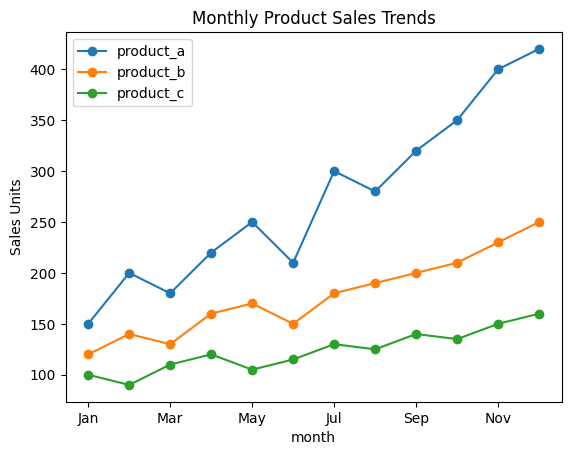

In [48]:
# Line Plot: Trends over time
df_sales.plot(x='month', y=['product_a', 'product_b', 'product_c'], kind='line', marker='o')
plt.title('Monthly Product Sales Trends')
plt.ylabel('Sales Units')



Text(0.5, 1.0, 'Product A Sales per Month')

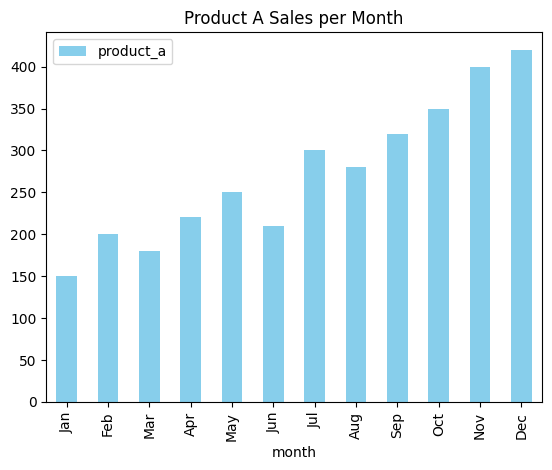

In [49]:
# Bar Plot: Product A performance by month
df_sales.plot(x='month', y='product_a', kind='bar', color='skyblue')
plt.title('Product A Sales per Month')



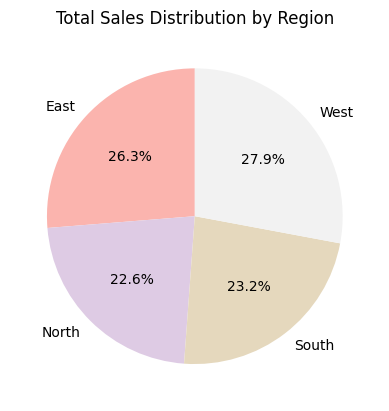

In [50]:
# Pie Chart: Total Sales (A+B+C) by Region
# We need to sum all products first
df_sales['total_sales'] = df_sales['product_a'] + df_sales['product_b'] + df_sales['product_c']
region_sales = df_sales.groupby('region')['total_sales'].sum()
region_sales.plot(kind='pie', autopct='%1.1f%%', startangle=90, cmap='Pastel1')
plt.title('Total Sales Distribution by Region')
plt.ylabel('') # Hides the redundant 'total_sales' label
plt.show()

SEABORN DISTRIBUTION PLOT

Text(0.5, 1.0, 'Distribution of Product A Sales')

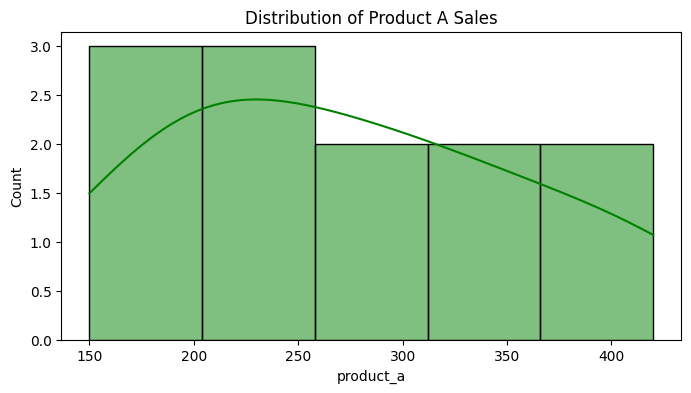

In [52]:
# Distribution Plot (Modern version of distplot)
plt.figure(figsize=(8, 4))
sns.histplot(df_sales['product_a'], kde=True, color='green')
plt.title('Distribution of Product A Sales')



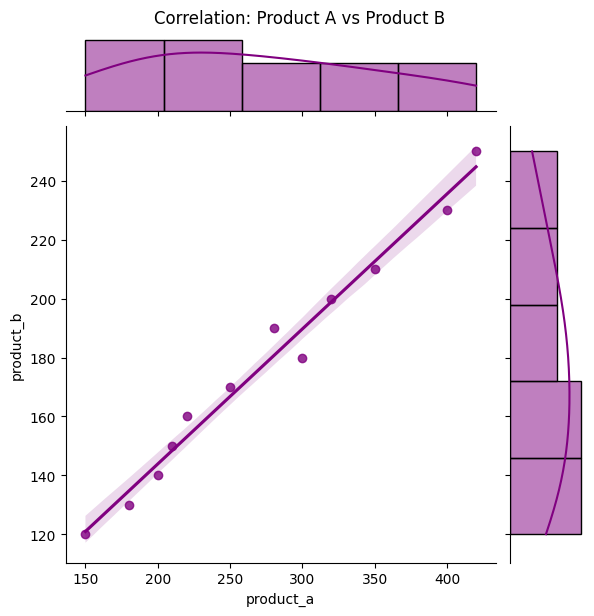

In [53]:
# Jointplot: Comparing Product A and Product B
# This shows individual distributions + a scatter plot
sns.jointplot(x='product_a', y='product_b', data=df_sales, kind='reg', color='purple')
plt.suptitle('Correlation: Product A vs Product B', y=1.02)
plt.show()

Seaborn Categorical Plots

C:\Users\aqib farooq\AppData\Local\Temp\ipykernel_14412\402492610.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='region', y='product_a', data=df_sales, palette='Set2')


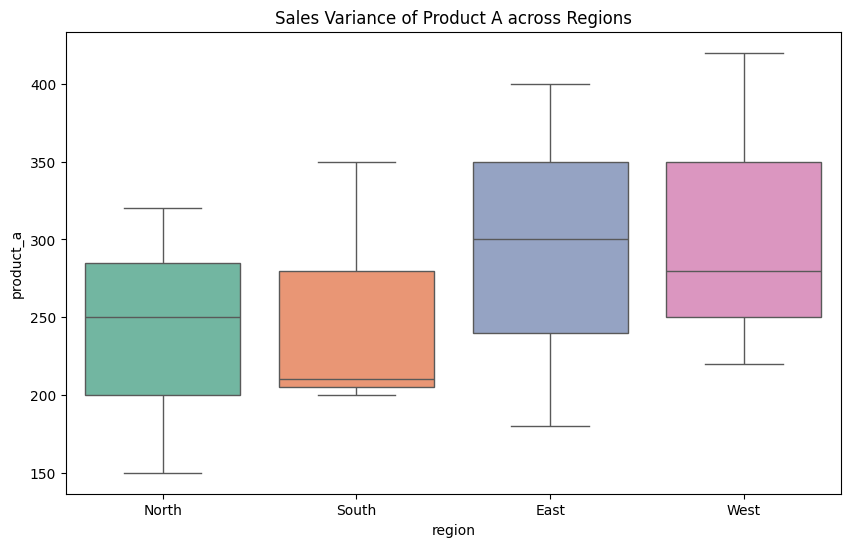

In [54]:
# Boxplot: Product A by Region
plt.figure(figsize=(10, 6))
sns.boxplot(x='region', y='product_a', data=df_sales, palette='Set2')
plt.title('Sales Variance of Product A across Regions')
plt.show()

C:\Users\aqib farooq\AppData\Local\Temp\ipykernel_14412\682492628.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='region', y='total_sales', data=df_sales, palette='magma')


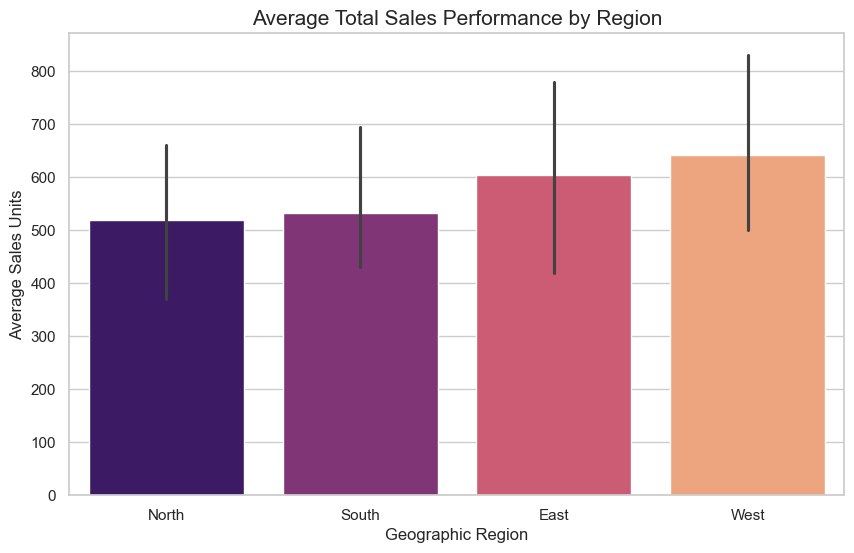

In [56]:

sns.set_theme(style="whitegrid")

# Create a barplot for Average Total Sales by Region
plt.figure(figsize=(10, 6))
sns.barplot(x='region', y='total_sales', data=df_sales, palette='magma')

# Adding Titles and Labels
plt.title('Average Total Sales Performance by Region', fontsize=15)
plt.xlabel('Geographic Region', fontsize=12)
plt.ylabel('Average Sales Units', fontsize=12)

#display
plt.show()

MATRIX PLOT

In [59]:
#Create correlation matrix of product columns
# We only want the numeric product columns for this
product_cols = df_sales[['product_a', 'product_b', 'product_c']]
corr_matrix = product_cols.corr()



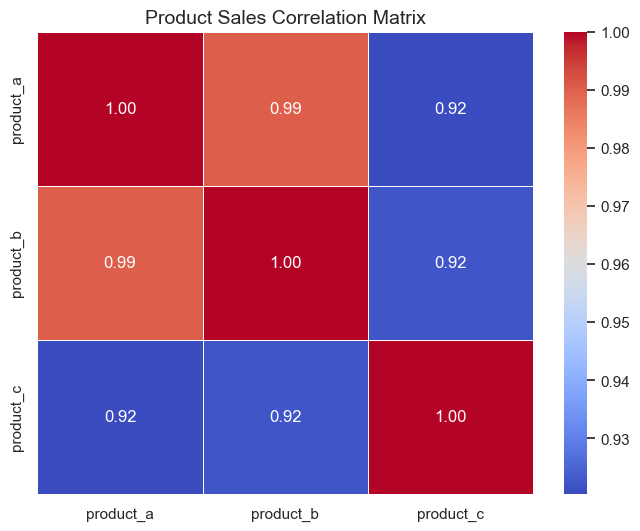

In [61]:
# Visualize using sns.heatmap()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)


plt.title('Product Sales Correlation Matrix', fontsize=14)
plt.show()

```**python**

ASSIGNMENT 3: Simple Linear Regression from Scratch
```


Objective: Implement linear regression using gradient descent.

Dataset:
Hours studied vs exam score


In [63]:
import numpy as np
import matplotlib.pyplot as plt

In [64]:
#create dataset
x = np.array([1,2,3,4,5,6,7,8,9,10])
y = np.array([40,50,60,70,80,90,95,100,110,120])

In [65]:
#initialize parameters
m = 0
b = 0
L = 0.01
epochs = 1000

n = float(len(x))

In [66]:
for i in range(epochs):
    y_pred = m*x+b

In [67]:
#implement cost function
cost = (1/n)* sum(y-y_pred)**2

In [68]:
#compute gradients
d_m = (-2/n)* sum(y-y_pred)**2

In [69]:
d_b = (-2/n)* sum(y-y_pred)**2

In [70]:
#update parameters
m = m - L * d_m
b = b - L * d_b

In [71]:
#print cost
if i % 100 == 0:
    print(f"epochs{i}:cost = {cost:.4f}")


In [72]:
#print final slope
print(f"\nFinal Slope (m): {m:.4f}")
print(f"Final Intercept (b): {b:.4f}")


Final Slope (m): 1328.4500
Final Intercept (b): 1328.4500


In [73]:
#make predictions
def predict(hours):
    return m * hours + b

print(f"Prediction for 4.5 hours: {predict(4.5):.2f}")
print(f"Prediction for 7.5 hours: {predict(7.5):.2f}")

Prediction for 4.5 hours: 7306.48
Prediction for 7.5 hours: 11291.83


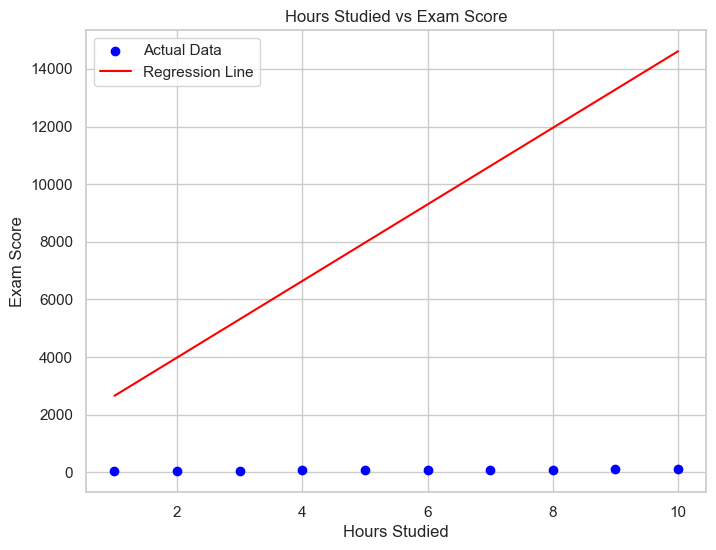

In [76]:
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', label='Actual Data') # Scatter plot
plt.plot(x, m*x + b, color='red', label='Regression Line') # Best fit line
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Hours Studied vs Exam Score')
plt.legend()
plt.show()